# Этап 5. Обучение и сравнение моделей

**Цель этапа:** обучить несколько классификаторов, сравнить их между собой и выбрать оптимальный алгоритм для каждой цели пользователя.

**Модели для сравнения:**
1. Логистическая регрессия
2. Дерево решений 
3. Случайный лес
4. Градиентный бустинг

**Метрики оценки:** Accuracy, Precision, Recall, F1-score, ROC-AUC

## 1. Загрузка данных

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Загружаем подготовленные выборки (Train/Test, без Val)
with open('../data/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

labels = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']

X_train, X_test = splits['X_train'], splits['X_test']
y_train_dict = splits['y_train']
y_test_dict  = splits['y_test']

print('Данные загружены и подготовлены успешно')
print('Доступные цели:', labels)
print('Размер Train:', X_train.shape)
print('Размер Test: ', X_test.shape)

Данные загружены и подготовлены успешно
Доступные цели: ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']
Размер Train: (320, 27)
Размер Test:  (80, 27)


## 2. Модели и сетки гиперпараметров

Для каждой модели задаём диапазон значений ключевых гиперпараметров — `GridSearchCV` перебере все комбинации и для каждой прогонит 5-fold кросс-валидацию на Train, оставив лучшую комбинацию по F1.

In [2]:
model_grids = {
    'Логистическая регрессия': (
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Дерево решений': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 8, None], 'min_samples_leaf': [1, 5, 10]}
    ),
    'Случайный лес': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_leaf': [1, 3]}
    ),
    'Градиентный бустинг': (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
    ),
}

print('Модели и размер сетки гиперпараметров:')
for name, (_, grid) in model_grids.items():
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)
    print(f'  {name:<28} {n_combos} комбинаций x 5 фолдов')

Модели и размер сетки гиперпараметров:
  Логистическая регрессия      4 комбинаций x 5 фолдов
  Дерево решений               12 комбинаций x 5 фолдов
  Случайный лес                12 комбинаций x 5 фолдов
  Градиентный бустинг          8 комбинаций x 5 фолдов


## 3. Подбор гиперпараметров через GridSearchCV (Train, 5-fold CV)

Для каждой цели и каждой модели запускаем `GridSearchCV` — он перебирает все комбинации параметров, для каждой считает среднее F1 по 5 фолдам, и оставляет (и переобучает на всём Train) лучшую комбинацию. 

In [3]:
SCORING = {
    'f1': 'f1',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
}

grid_results = {}

for label in labels:
    y_train = y_train_dict[label]
    grid_results[label] = {}

    print(f'--- {label} ---')
    for name, (estimator, param_grid) in model_grids.items():
        gs = GridSearchCV(
            estimator, param_grid,
            cv=5, scoring=SCORING, refit='f1', n_jobs=-1
        )
        gs.fit(X_train, y_train)

        best_idx = gs.best_index_
        metrics_at_best = {
            m: gs.cv_results_[f'mean_test_{m}'][best_idx] for m in SCORING
        }

        grid_results[label][name] = {
            'best_params': gs.best_params_,
            'best_model':  gs.best_estimator_,  # уже переобучен на всём Train
            **metrics_at_best,  # f1, accuracy, precision, recall, roc_auc
        }
        print(
            f'  {name:<28} F1={metrics_at_best["f1"]:.3f}  '
            f'Acc={metrics_at_best["accuracy"]:.3f}  '
            f'Prec={metrics_at_best["precision"]:.3f}  '
            f'Rec={metrics_at_best["recall"]:.3f}  '
            f'ROC-AUC={metrics_at_best["roc_auc"]:.3f}  '
            f'params: {gs.best_params_}'
        )
    print()

--- Похудение ---
  Логистическая регрессия      F1=0.861  Acc=0.884  Prec=0.889  Rec=0.840  ROC-AUC=0.958  params: {'C': 10}
  Дерево решений               F1=0.930  Acc=0.941  Prec=0.941  Rec=0.920  ROC-AUC=0.938  params: {'max_depth': 8, 'min_samples_leaf': 1}
  Случайный лес                F1=0.924  Acc=0.934  Prec=0.915  Rec=0.935  ROC-AUC=0.989  params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
  Градиентный бустинг          F1=0.950  Acc=0.956  Prec=0.937  Rec=0.964  ROC-AUC=0.990  params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

--- Набор массы ---
  Логистическая регрессия      F1=0.833  Acc=0.844  Prec=0.804  Rec=0.868  ROC-AUC=0.908  params: {'C': 0.1}
  Дерево решений               F1=0.932  Acc=0.938  Prec=0.921  Rec=0.945  ROC-AUC=0.938  params: {'max_depth': 5, 'min_samples_leaf': 1}
  Случайный лес                F1=0.939  Acc=0.944  Prec=0.929  Rec=0.951  ROC-AUC=0.987  params: {'max_depth': 10, 'min_samples_leaf': 3, 'n_estimat

## 4. Визуализация сравнения моделей

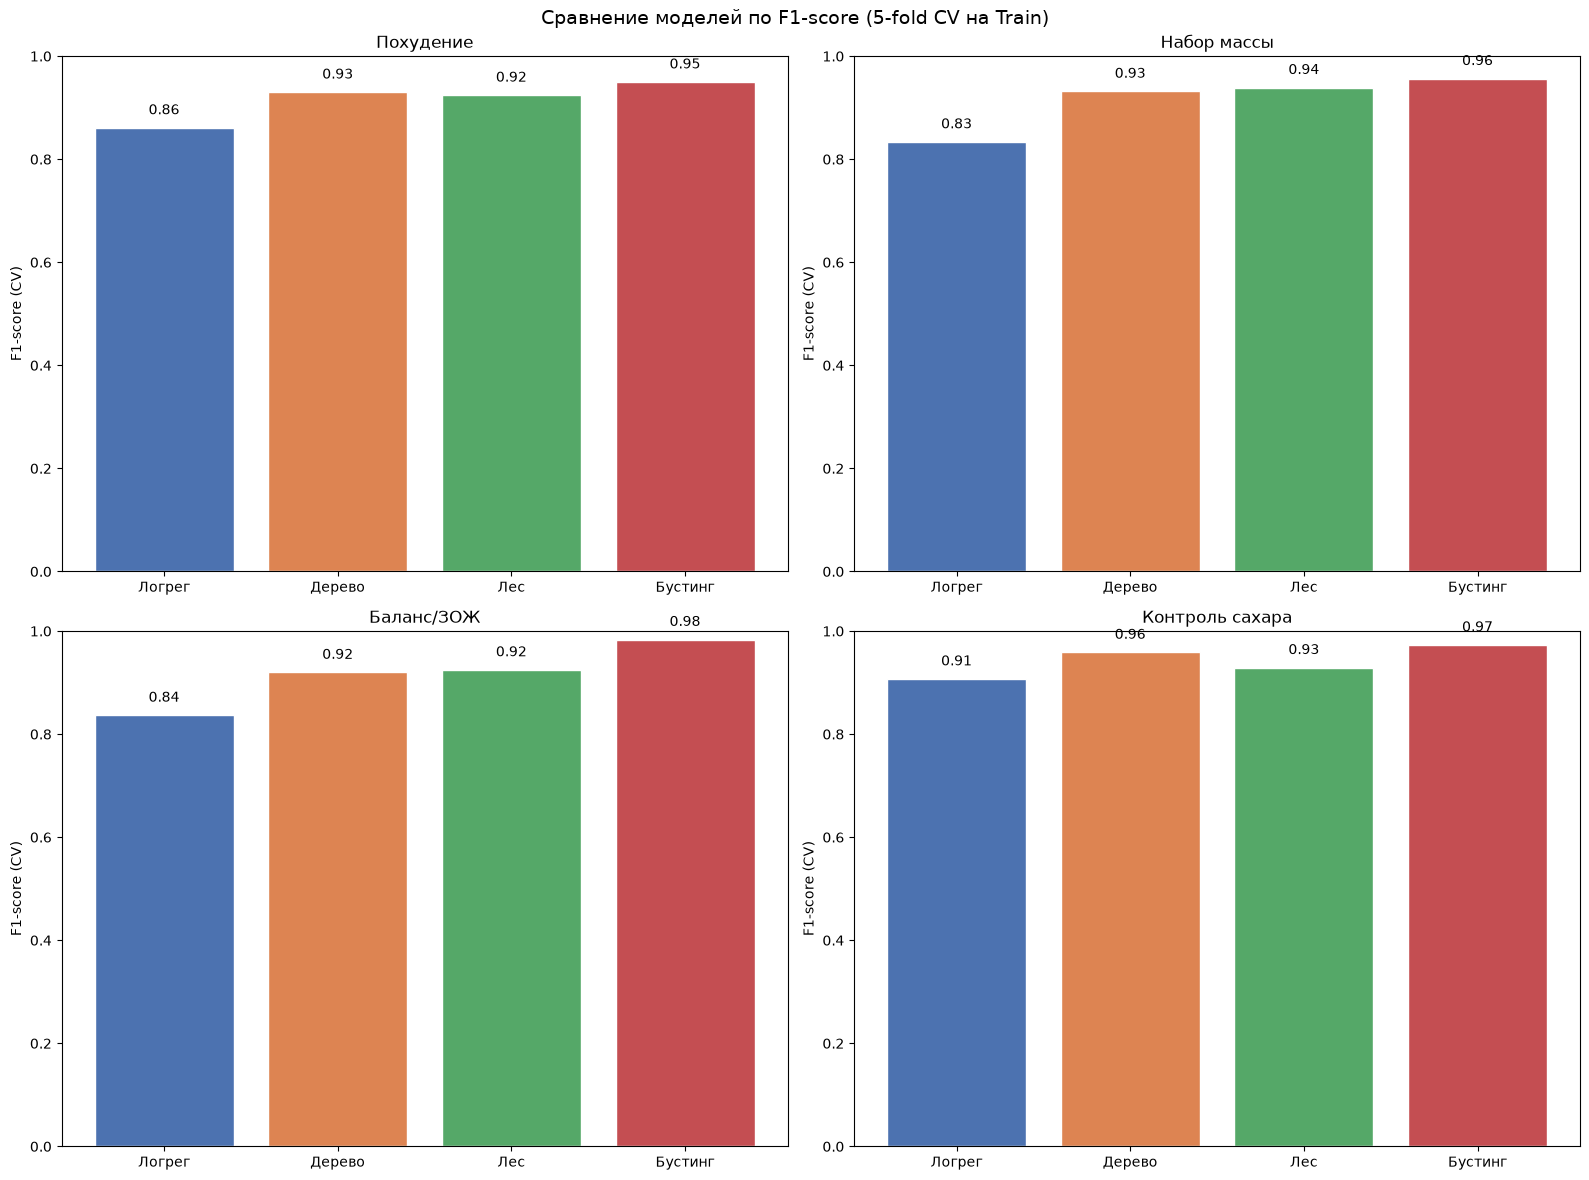

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_names = list(model_grids.keys())
short_names = ['Логрег', 'Дерево', 'Лес', 'Бустинг']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, label in zip(axes, labels):
    f1_scores = [grid_results[label][name]['f1'] for name in model_names]
    bars = ax.bar(short_names, f1_scores, color=colors, edgecolor='white')
    ax.set_title(label, fontsize=12)
    ax.set_ylabel('F1-score (CV)')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Сравнение моделей по F1-score (5-fold CV на Train)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Выбор лучшей модели для каждой цели

In [5]:

best_models = {}

print('Лучшая модель для каждой цели (по F1 на кросс-валидации):')
print()
for label in labels:
    best_name = max(grid_results[label], key=lambda x: grid_results[label][x]['f1'])
    best = grid_results[label][best_name]
    best_models[label] = {'name': best_name, 'model': best['best_model'], 'params': best['best_params']}
    print(
        f'  {label:<20} -> {best_name}  '
        f'(F1={best["f1"]:.3f}, Acc={best["accuracy"]:.3f}, ROC-AUC={best["roc_auc"]:.3f})'
    )
    print(f' params: {best["best_params"]}')

Лучшая модель для каждой цели (по F1 на кросс-валидации):

  Похудение            -> Градиентный бустинг  (F1=0.950, Acc=0.956, ROC-AUC=0.990)
 params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
  Набор массы          -> Градиентный бустинг  (F1=0.956, Acc=0.959, ROC-AUC=0.990)
 params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Баланс/ЗОЖ           -> Градиентный бустинг  (F1=0.983, Acc=0.988, ROC-AUC=0.995)
 params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  Контроль сахара      -> Градиентный бустинг  (F1=0.973, Acc=0.981, ROC-AUC=0.992)
 params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}


# 6. Финальная оценка на Test выборке



In [6]:
test_results = {}

print('ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ на Test выборке:')
print()
print(f'{"Цель":<20} {"Лучшая модель":<30} {"Accuracy":>9} {"F1":>8} {"ROC-AUC":>9}')
print('-' * 80)

for label in labels:
    y_test = y_test_dict[label]
    best = best_models[label]
    model = best['model']

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    test_results[label] = {
        'model': best['name'], 'accuracy': acc, 'f1': f1, 'roc_auc': roc_auc,
        'y_pred': y_pred, 'y_test': y_test
    }
    print(f'{label:<20} {best["name"]:<30} {acc:>9.3f} {f1:>8.3f} {roc_auc:>9.3f}')

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ на Test выборке:

Цель                 Лучшая модель                   Accuracy       F1   ROC-AUC
--------------------------------------------------------------------------------
Похудение            Градиентный бустинг                0.950    0.947     0.983
Набор массы          Градиентный бустинг                0.988    0.986     0.997
Баланс/ЗОЖ           Градиентный бустинг                0.988    0.984     0.999
Контроль сахара      Градиентный бустинг                0.975    0.963     0.995


## 7. Матрицы ошибок (Confusion Matrix)

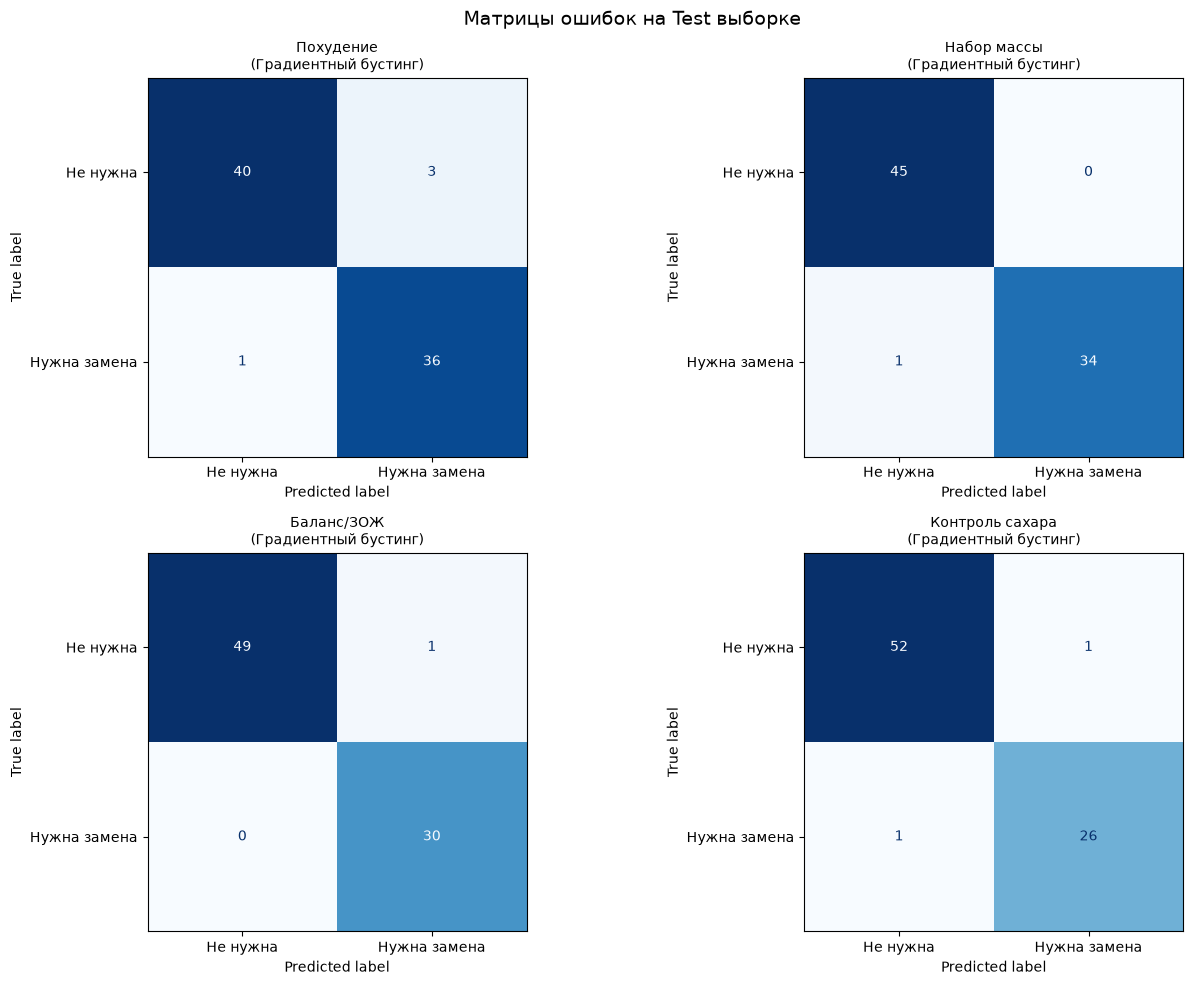

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    res = test_results[label]
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Не нужна', 'Нужна замена'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{label}\n({res["model"]})', fontsize=10)

plt.suptitle('Матрицы ошибок на Test выборке', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Важность признаков (Feature Importance)


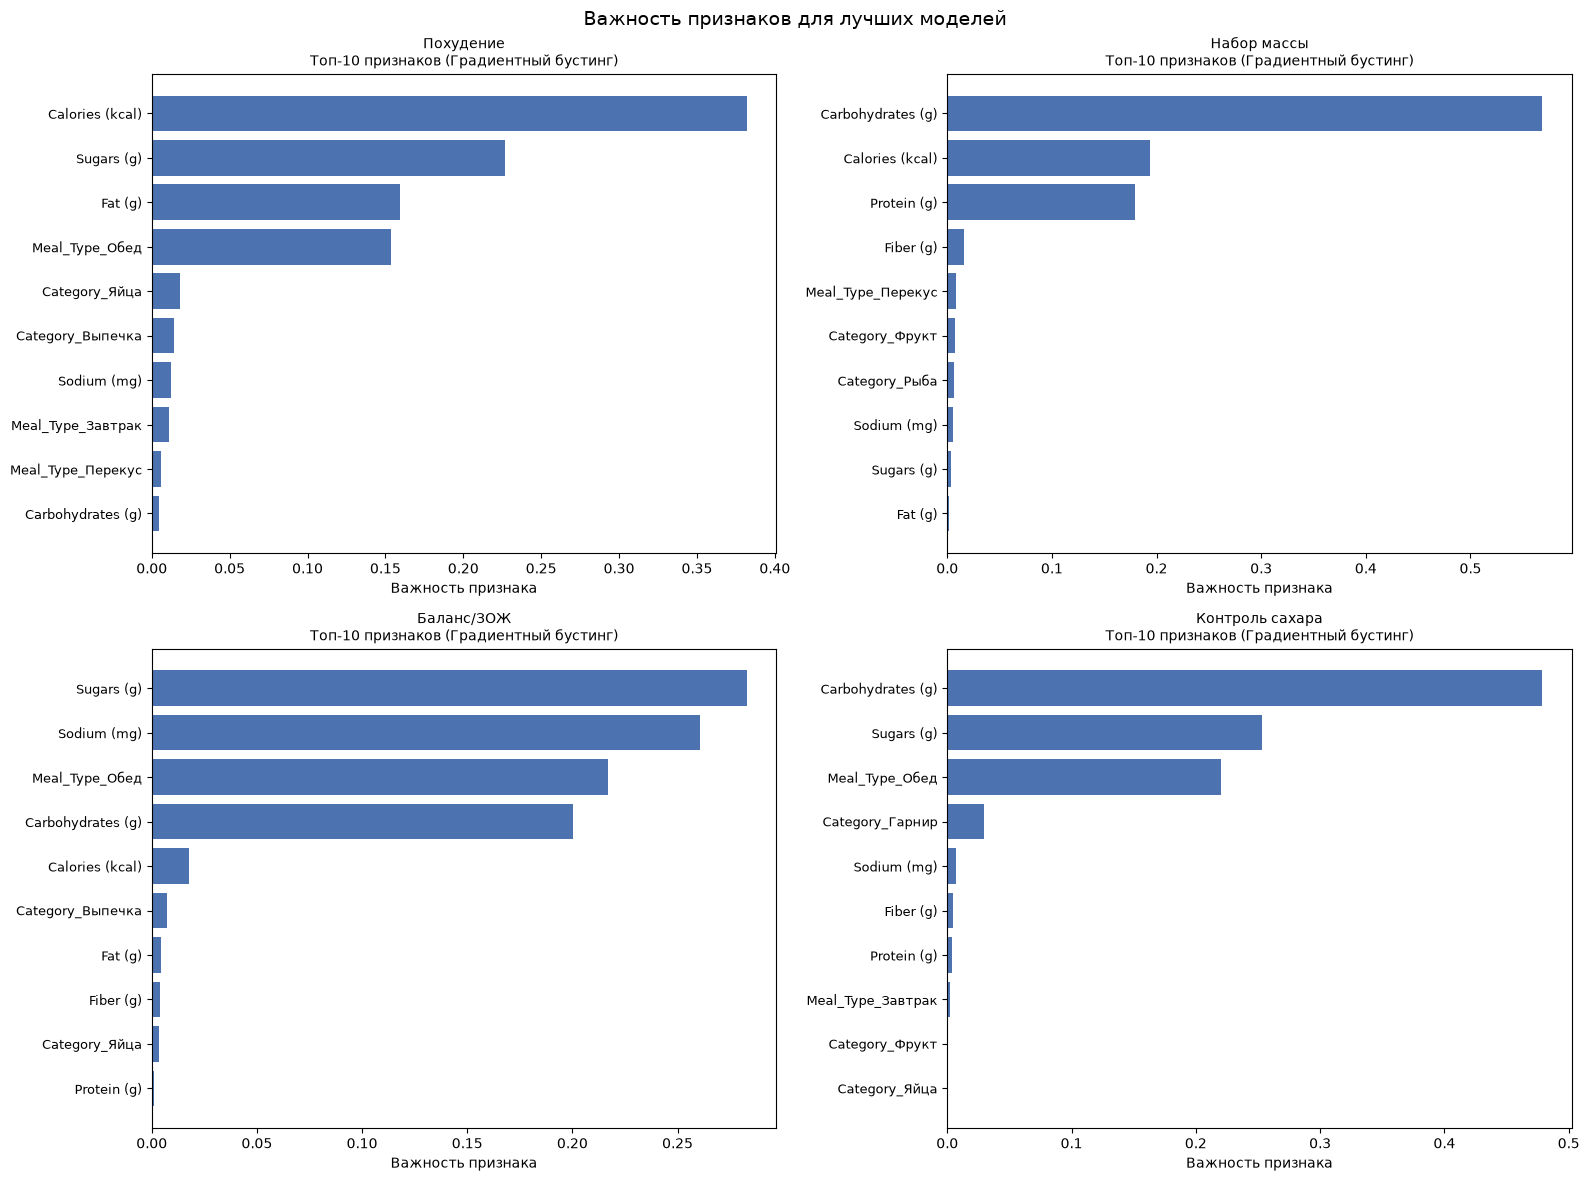

In [8]:
with open('../data/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    best = best_models[label]
    model = best['model']

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:10]
        top_features = [feature_cols[i] for i in indices]
        top_scores   = importances[indices]

        ax.barh(range(len(top_features)), top_scores[::-1], color='#4C72B0')
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features[::-1], fontsize=9)
        ax.set_title(f'{label}\nТоп-10 признаков ({best["name"]})', fontsize=10)
        ax.set_xlabel('Важность признака')
    else:
        ax.text(0.5, 0.5, f'{best["name"]}\nне поддерживает\nfeature importance',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label)

plt.suptitle('Важность признаков для лучших моделей', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Сохранение лучших моделей

In [9]:

best_to_save = {label: best_models[label]['model'] for label in labels}

with open('../data/best_models.pkl', 'wb') as f:
    pickle.dump(best_to_save, f)

print('Лучшие модели сохранены в ../data/best_models.pkl')
print()
print('Итоговые лучшие модели:')
for label in labels:
    print(f'  {label}: {best_models[label]["name"]}  {best_models[label]["params"]}')

Лучшие модели сохранены в ../data/best_models.pkl

Итоговые лучшие модели:
  Похудение: Градиентный бустинг  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
  Набор массы: Градиентный бустинг  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Баланс/ЗОЖ: Градиентный бустинг  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  Контроль сахара: Градиентный бустинг  {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
